# Missing Values


`causal-ts` supports three strategies for time series with NaN entries. All strategies work across all algorithms (CDNOTS, CEDAR, GRACE) via the `impute` parameter.

| Strategy | `impute=` | When to use |
|---|---|---|
| Pairwise-complete | `None` (default) | Sparse missingness (<5%), no systematic pattern |
| VAR-EM | `"var_em"` | Moderate missingness, symmetric fill using multivariate temporal structure |
| Causal iterative | `"causal_iterative"` | Moderate missingness, iteratively refine imputation using the discovered graph (CDNOTS only) |

**Pairwise-complete** (default): each CI test drops rows where any of X, Y, or Z is NaN for that specific triple. Statistically safe but wastes cross-variable information.

**VAR-EM**: fits a VAR(p) model via EM, imputes NaN positions with fitted values, repeats until convergence. Symmetric — no directional prior assumed.

**Causal iterative**: warm-starts with VAR-EM, then alternates between running CDNOTS to get the graph and re-imputing each variable using only its Markov blanket (parents ∪ children ∪ parents-of-children) via Ridge regression. Only available with CDNOTS; CEDAR and GRACE fall back to VAR-EM.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import causalts.plotting as tp
from causalts import run_cdnots, run_cdnots_plus
from causalts.ci_tests import ParCorrGPU, SplitKCIGPU
from causalts.synthetic_data.synthetic_datasets import ex2, henon_chain
from causalts.utils import evaluate_graph

T_SMALL, T_LARGE = 200, 500

res_ex2_small  = ex2(seed=42, T=T_SMALL)
res_ex2_large  = ex2(seed=42, T=T_LARGE)
res_hc_small   = henon_chain(seed=42, T=T_SMALL)
res_hc_large   = henon_chain(seed=42, T=T_LARGE)

for res, t in [
    (res_ex2_small, "T=200"), (res_ex2_large, "T=500"),
    (res_hc_small,  "T=200"), (res_hc_large,  "T=500"),
]:
    print(f"{res['name']} {t}: d={res['df'].shape[1]}, T={len(res['df'])}, max_lag={res['max_lag']}")

6-Node Linear VAR T=200: d=6, T=200, max_lag=3
6-Node Linear VAR T=500: d=6, T=500, max_lag=3
Hénon Chain T=200: d=5, T=200, max_lag=2
Hénon Chain T=500: d=5, T=500, max_lag=2


In [4]:
def introduce_nan(df, frac=0.10, seed=99):
    rng = np.random.default_rng(seed)
    arr = df.values.copy()
    mask = rng.random(arr.shape) < frac
    arr[mask] = np.nan
    return pd.DataFrame(arr, columns=df.columns), mask.sum()

_NAN_STRATEGIES = [
    ("Pairwise",  None,               {}),
    ("VAR-EM",    "var_em",           {"p": 1}),
    ("Causal It", "causal_iterative", {"n_iter": 2}),
]
STRAT_COLS   = ["clean", "Pairwise", "VAR-EM", "Causal It"]
STRAT_LABELS = STRAT_COLS
METHODS      = ["cdnots+", "cdnots"]


def run_scenario(df_clean, df_nan, max_lag, make_ci, alpha=0.01):
    """Run both cdnots+ and cdnots for all strategies. make_ci() returns a fresh CI test."""
    out = {}
    for method, runner in [("cdnots+", run_cdnots_plus), ("cdnots", run_cdnots)]:
        out[method] = {}
        out[method]["clean"] = runner(
            df=df_clean, indep_test=make_ci(), num_lags=max_lag,
            include_C=False, alpha=alpha,
        ).cg_tig
        for label, impute, ikw in _NAN_STRATEGIES:
            out[method][label] = runner(
                df=df_nan, indep_test=make_ci(), num_lags=max_lag,
                include_C=False, alpha=alpha,
                impute=impute, impute_kwargs=ikw,
            ).cg_tig
    return out


def plot_scenario(key, scenarios, figsize=(22, 9)):
    sc        = scenarios[key]
    true_g    = sc["true_graph"]
    var_names = sc["var_names"]
    n_cols    = 1 + len(STRAT_LABELS)

    fig, axes = plt.subplots(len(METHODS), n_cols, figsize=figsize)
    fig.suptitle(key, fontsize=15, fontweight="bold")

    _, _, pos = tp.plot_graph(
        graph=true_g, var_names=var_names,
        arrow_linewidth=3, show_colorbar=False,
        fig_ax=(fig, axes[0, 0]), return_pos=True,
    )
    axes[0, 0].set_title("True Graph", fontsize=11)

    for row_idx, method in enumerate(METHODS):
        if row_idx > 0:
            tp.plot_graph(
                graph=true_g, var_names=var_names, node_pos=pos,
                arrow_linewidth=3, show_colorbar=False,
                fig_ax=(fig, axes[row_idx, 0]),
            )
            axes[row_idx, 0].set_title("True Graph", fontsize=11)

        for col_idx, label in enumerate(STRAT_LABELS, start=1):
            g = sc["results"][method][label]
            m = evaluate_graph(g, true_g)
            tp.compare_graphs(
                graph_true=true_g, graph_discovered=g,
                var_names=var_names, node_pos=pos,
                arrow_linewidth=3, legend_loc=None,
                show_legend=(row_idx == 0 and col_idx == 1),
                fig_ax=(fig, axes[row_idx, col_idx]),
            )
            axes[row_idx, col_idx].set_title(
                f"{label}\nF1={m['F1']:.3f}, SHD={m['SHD']}", fontsize=10
            )

        axes[row_idx, 0].set_ylabel(method, fontsize=13, fontweight="bold", labelpad=10)

    plt.tight_layout()
    plt.show()

## Example 1: VAR — Linear, d=6, max_lag=3

Linear VAR model with 6 variables. CI test: **PartialCorr** (correctly specified for linear data).

In [11]:
make_parcorr = lambda: ParCorrGPU(data=np.zeros((2, 2)))

scenarios_ex2 = {}
for t_label, res in [("T=200", res_ex2_small), ("T=500", res_ex2_large)]:
    df_clean = res["df"]
    df_nan, n_missing = introduce_nan(df_clean)
    key = f"{res['name']} {t_label}"
    print(f"Running {key}  ({n_missing}/{df_clean.size} NaN = {100*n_missing/df_clean.size:.1f}%)")
    scenarios_ex2[key] = dict(
        results    = run_scenario(df_clean, df_nan, res["max_lag"], make_parcorr),
        true_graph = res["ground_truth"],
        var_names  = res["df"].columns.tolist(),
    )

print()
for key, sc in scenarios_ex2.items():
    true_g = sc["true_graph"]
    print(f"  {key}")
    print(f"  {'Strategy':<12} {'cdnots+ F1':>11} {'cdnots+ SHD':>12} {'cdnots F1':>10} {'cdnots SHD':>11}")
    print("  " + "-" * 60)
    for col in STRAT_COLS:
        mp = evaluate_graph(sc["results"]["cdnots+"][col], true_g)
        mb = evaluate_graph(sc["results"]["cdnots"][col],  true_g)
        print(f"  {col:<12} {mp['F1']:>11.3f} {mp['SHD']:>12} {mb['F1']:>10.3f} {mb['SHD']:>11}")
    print()

Running 6-Node Linear VAR T=200  (102/1200 NaN = 8.5%)
Running 6-Node Linear VAR T=500  (298/3000 NaN = 9.9%)

  6-Node Linear VAR T=200
  Strategy      cdnots+ F1  cdnots+ SHD  cdnots F1  cdnots SHD
  ------------------------------------------------------------
  clean              0.952            1      0.842           3
  Pairwise           0.952            1      0.842           3
  VAR-EM             0.909            2      0.842           3
  Causal It          0.952            1      0.842           3

  6-Node Linear VAR T=500
  Strategy      cdnots+ F1  cdnots+ SHD  cdnots F1  cdnots SHD
  ------------------------------------------------------------
  clean              0.952            1      0.842           3
  Pairwise           0.909            2      0.842           3
  VAR-EM             0.870            3      0.842           3
  Causal It          0.833            4      0.800           4



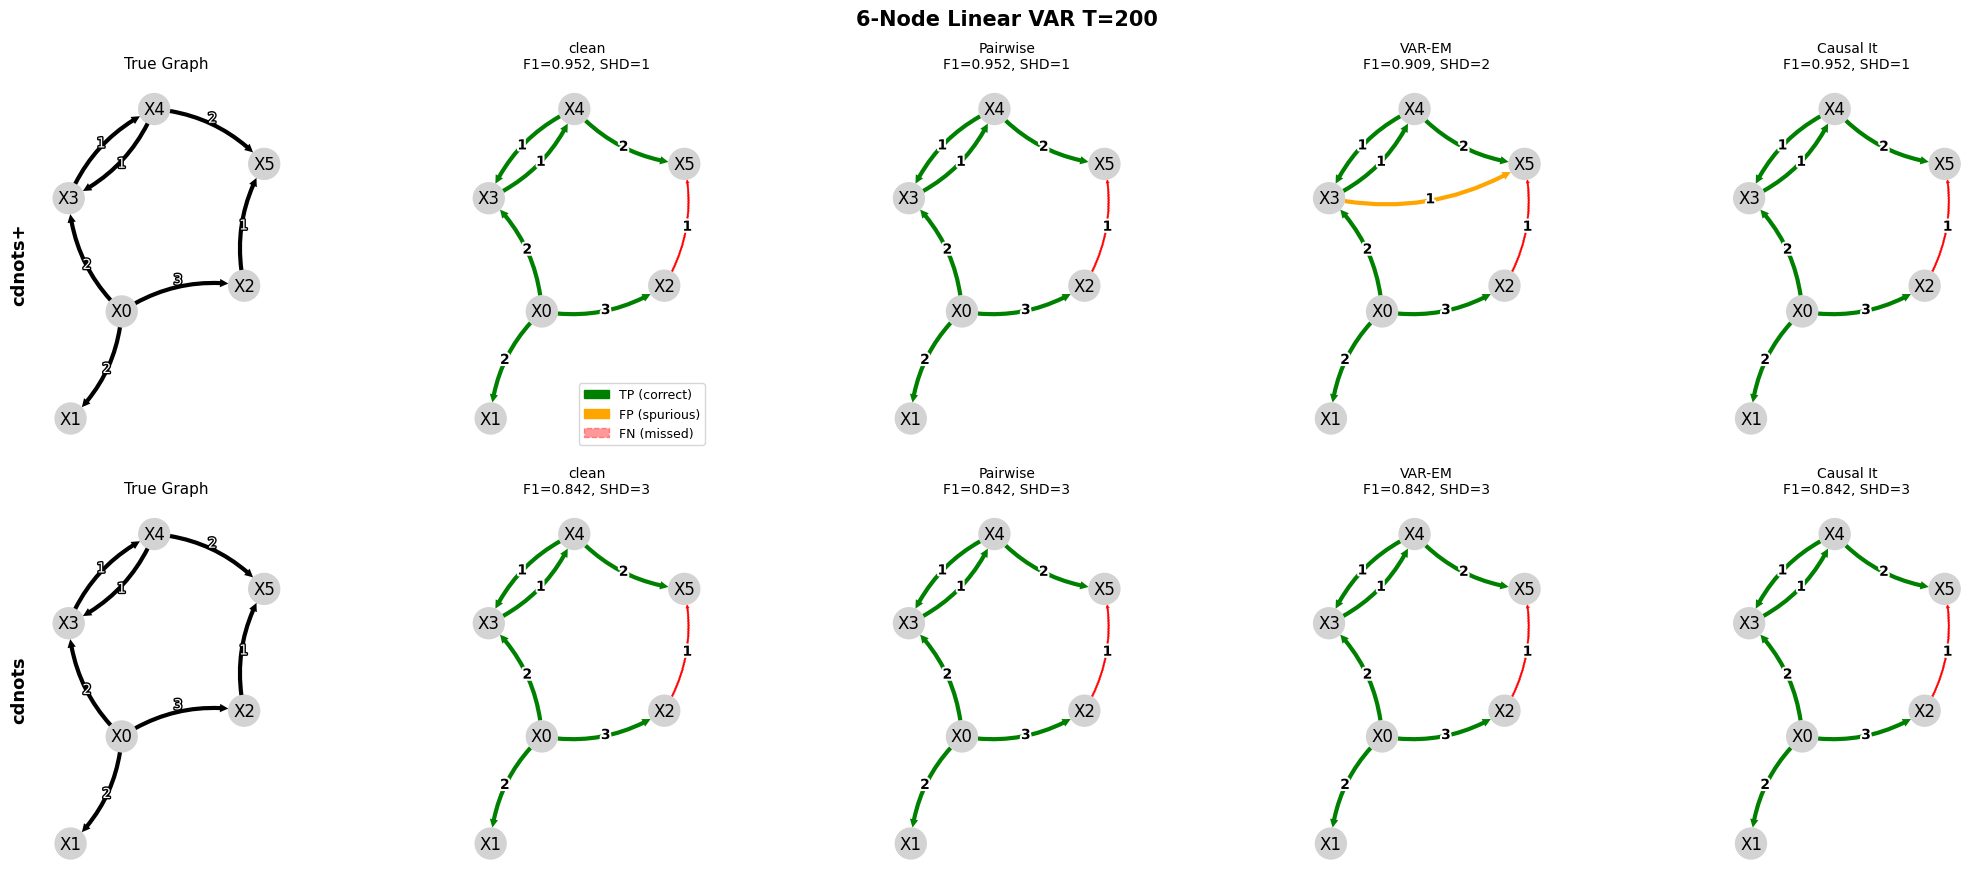

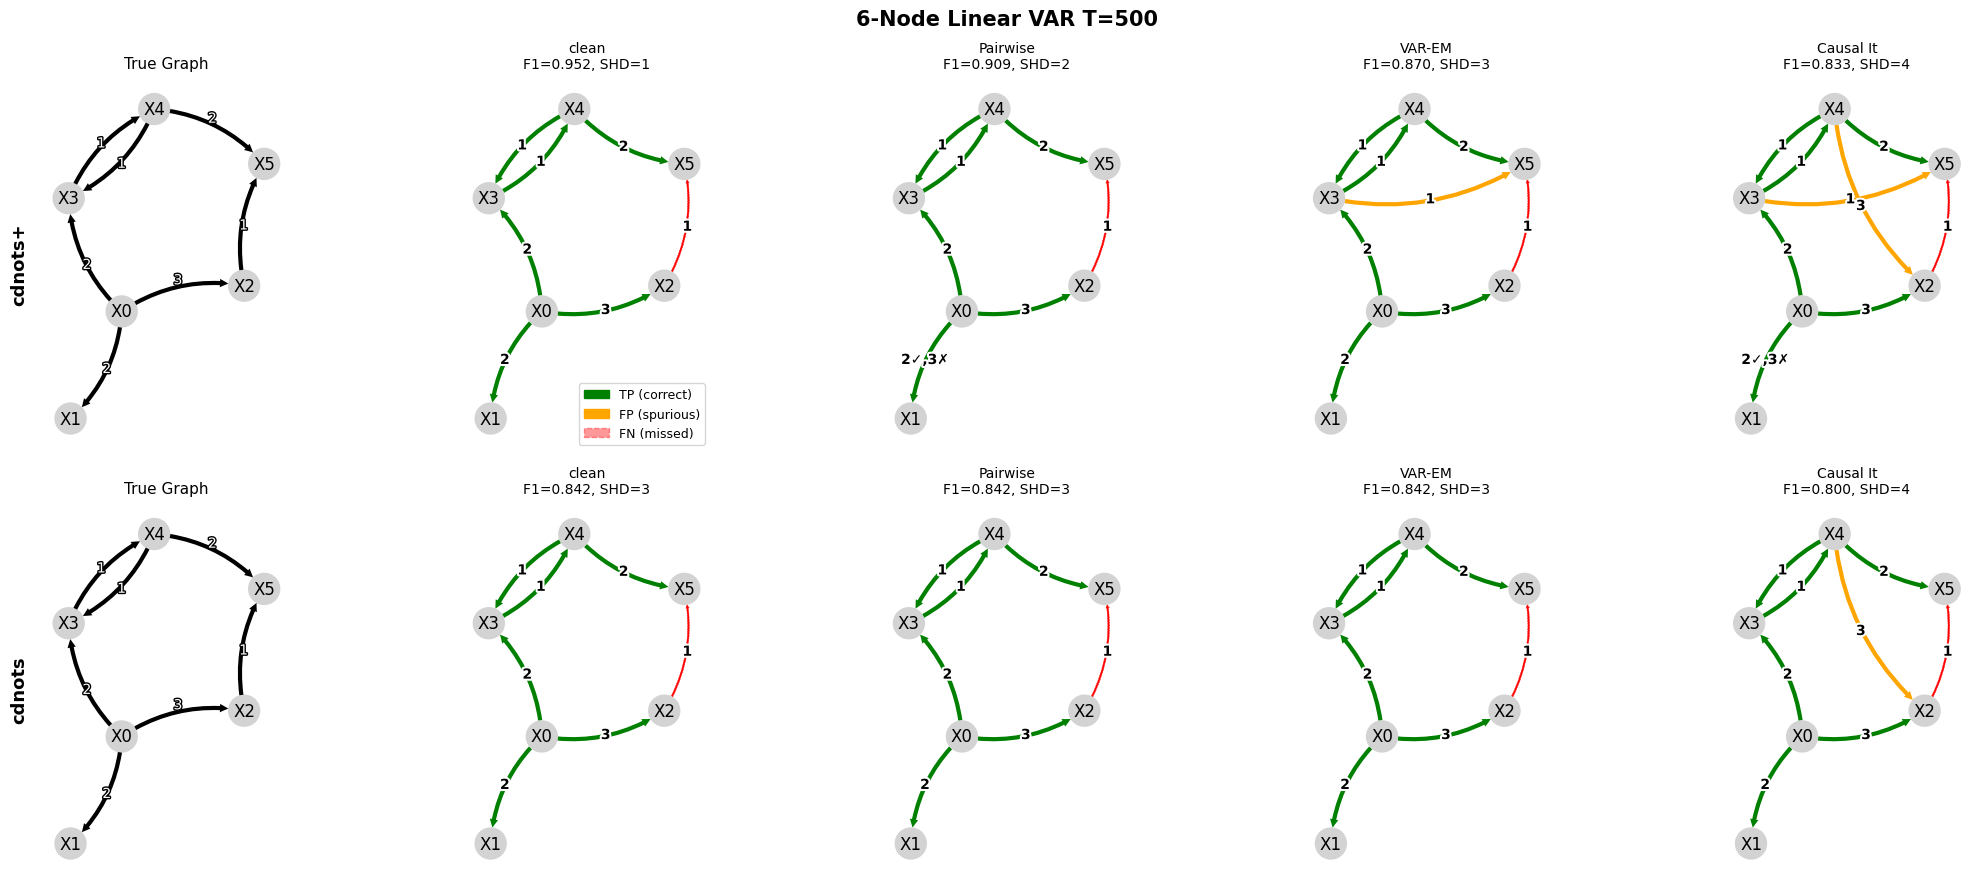

In [12]:
for key in scenarios_ex2:
    plot_scenario(key, scenarios_ex2)

## Example 2: Hénon Chain — Nonlinear, d=5, max_lag=2

Coupled Hénon maps with quadratic dynamics (`x[t] = 1.4 - mix²+ 0.3·x[t-2]`). PartialCorr is misspecified here; comparing against **SplitKCIGPU** (kernel nonlinear test, 10–20× faster than KCI, no functional form assumption).

In [13]:
make_splitkci = lambda: SplitKCIGPU(data=np.zeros((2, 2)))
hc_name = res_hc_small["name"]  # "Hénon Chain"

scenarios_hc = {}
for t_label, res in [("T=200", res_hc_small), ("T=500", res_hc_large)]:
    df_clean   = res["df"]
    df_nan, _  = introduce_nan(df_clean)
    max_lag    = res["max_lag"]
    true_graph = res["ground_truth"]
    var_names  = res["df"].columns.tolist()

    for ci_name, make_ci in [("ParCorr", make_parcorr), ("SplitKCI", make_splitkci)]:
        key = f"{hc_name} {t_label} {ci_name}"
        print(f"Running {key} ...")
        scenarios_hc[key] = dict(
            results    = run_scenario(df_clean, df_nan, max_lag, make_ci),
            true_graph = true_graph,
            var_names  = var_names,
        )

print("\nDone.")

Running Hénon Chain T=200 ParCorr ...
Running Hénon Chain T=200 SplitKCI ...
Running Hénon Chain T=500 ParCorr ...
Running Hénon Chain T=500 SplitKCI ...

Done.


In [14]:
for t_label in ["T=200", "T=500"]:
    key_pc = f"{hc_name} {t_label} ParCorr"
    key_sk = f"{hc_name} {t_label} SplitKCI"
    true_g = scenarios_hc[key_pc]["true_graph"]

    print(f"\n  {hc_name} {t_label}")
    print(f"  {'Strategy':<12} {'method':<9} {'ParCorr F1':>11} {'ParCorr SHD':>12} {'SplitKCI F1':>12} {'SplitKCI SHD':>13}")
    print("  " + "-" * 73)
    for method in METHODS:
        for col in STRAT_COLS:
            mp = evaluate_graph(scenarios_hc[key_pc]["results"][method][col], true_g)
            ms = evaluate_graph(scenarios_hc[key_sk]["results"][method][col], true_g)
            print(f"  {col:<12} {method:<9} {mp['F1']:>11.3f} {mp['SHD']:>12} {ms['F1']:>12.3f} {ms['SHD']:>13}")
        print()


  Hénon Chain T=200
  Strategy     method     ParCorr F1  ParCorr SHD  SplitKCI F1  SplitKCI SHD
  -------------------------------------------------------------------------
  clean        cdnots+         0.560           11        0.667             8
  Pairwise     cdnots+         0.545           10        0.720             7
  VAR-EM       cdnots+         0.615           10        0.769             6
  Causal It    cdnots+         0.609            9        0.583            10

  clean        cdnots          0.545           10        0.720             7
  Pairwise     cdnots          0.400           12        0.545            10
  VAR-EM       cdnots          0.476           11        0.720             7
  Causal It    cdnots          0.609            9        0.720             7


  Hénon Chain T=500
  Strategy     method     ParCorr F1  ParCorr SHD  SplitKCI F1  SplitKCI SHD
  -------------------------------------------------------------------------
  clean        cdnots+         0.5

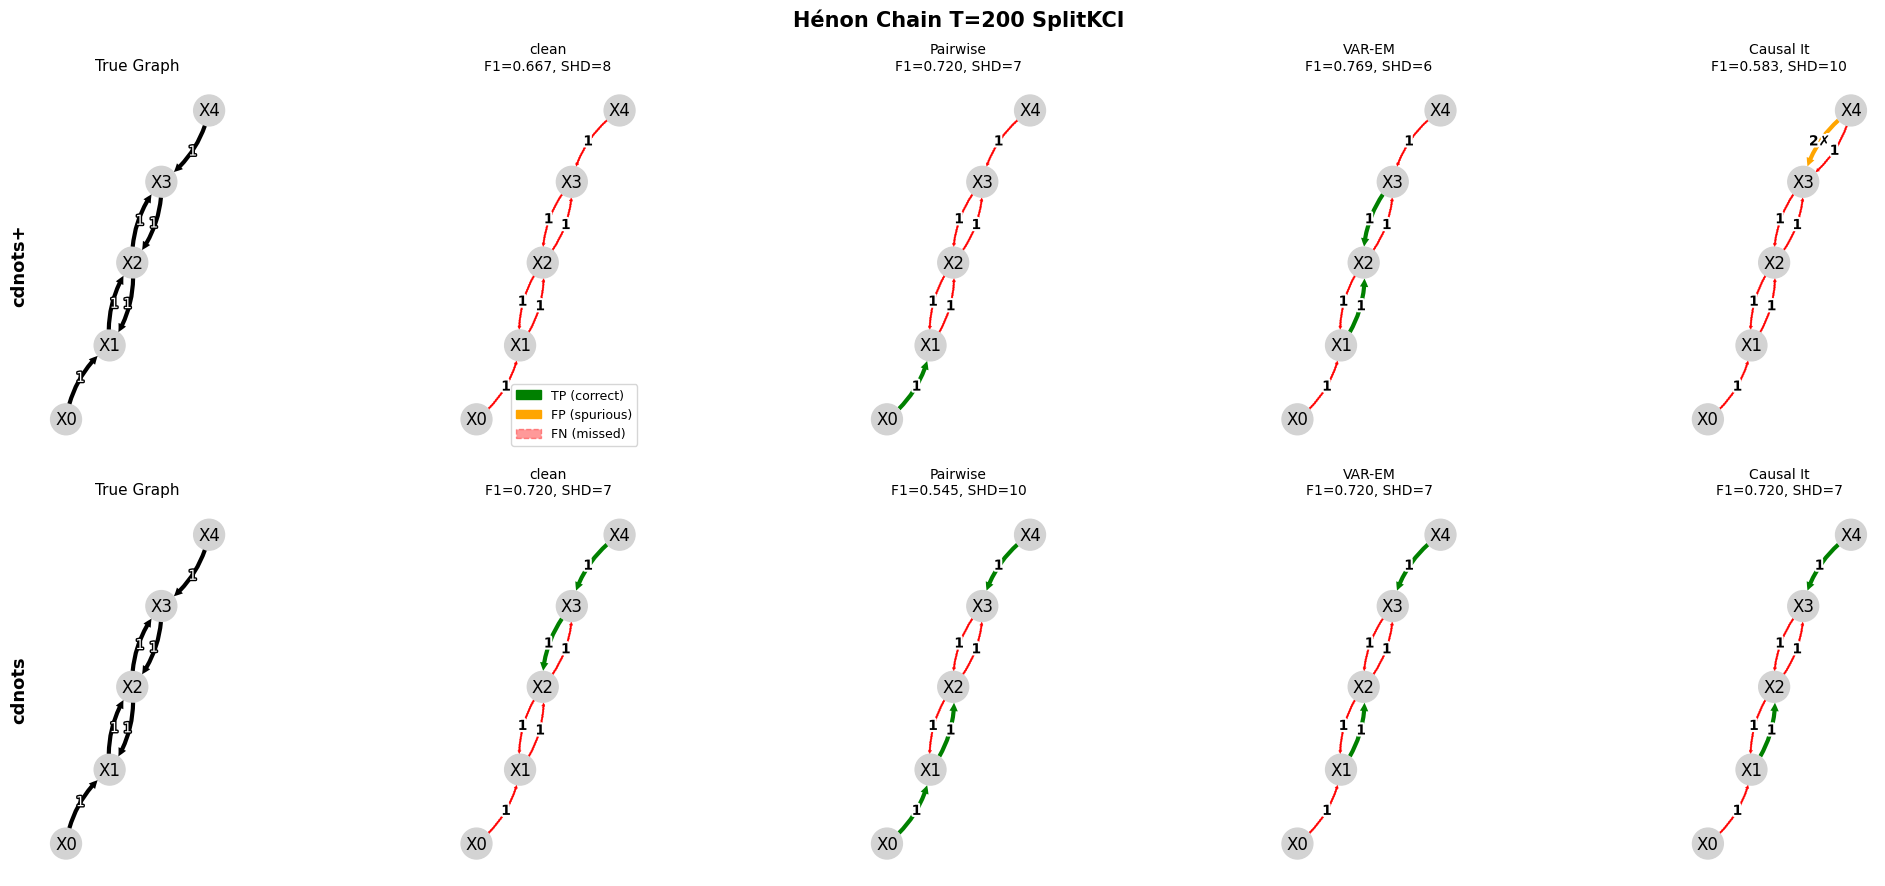

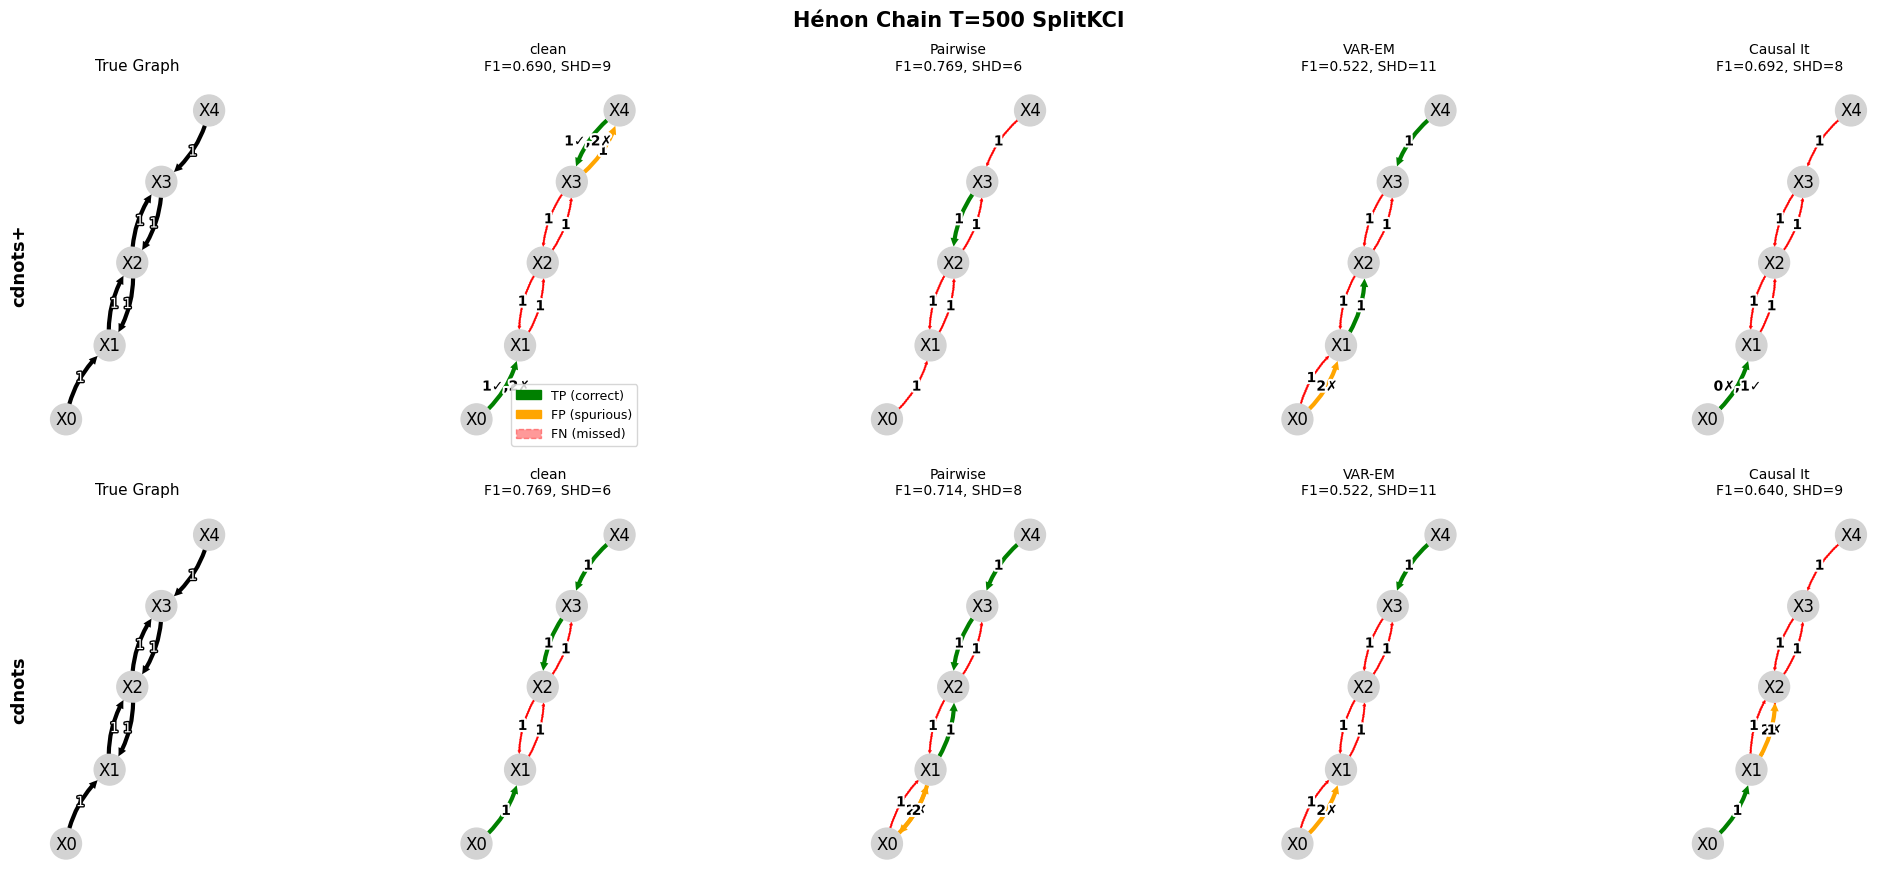

In [15]:
for t_label in ["T=200", "T=500"]:
    plot_scenario(f"{hc_name} {t_label} SplitKCI", scenarios_hc)